In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv('../results/outputs/Selected/train_top10_features.csv')
test_df = pd.read_csv('../results/outputs/Selected/test_top10_features.csv')

train_df_pca = pd.read_csv('../results/outputs/PCA/pca_train.csv')
test_df_pca = pd.read_csv('../results/outputs/PCA/pca_test.csv')

In [3]:
feature_cols = [c for c in train_df.columns if c != "target"]

x_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [4]:
feature_cols = [c for c in train_df_pca.columns if c != "target"]

x_train_pca = train_df_pca[feature_cols]
y_train_pca = train_df_pca["target"]

x_test_pca = test_df_pca[feature_cols]
y_test_pca = test_df_pca["target"]

In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, accuracy_score

In [6]:
#First train with the ANOVA-10 features

In [7]:
lda = LinearDiscriminantAnalysis()
lda.fit(x_train, y_train)

lda_preds = lda.predict(x_test)
lda_accuracy = accuracy_score(y_test, lda_preds)

print("LDA Accuracy:", lda_accuracy)
print(classification_report(y_test, lda_preds))

LDA Accuracy: 0.8909090909090909
              precision    recall  f1-score   support

           0       0.88      0.86      0.87        74
           1       1.00      0.89      0.94        72
           2       0.82      0.92      0.87        74

    accuracy                           0.89       220
   macro avg       0.90      0.89      0.89       220
weighted avg       0.90      0.89      0.89       220



In [8]:
#Try with PCA features

In [9]:
lda_pca = LinearDiscriminantAnalysis()
lda_pca.fit(x_train_pca, y_train_pca)

lda_preds_pca = lda_pca.predict(x_test_pca)
lda_accuracy_pca = accuracy_score(y_test_pca, lda_preds_pca)

print("LDA Accuracy (PCA):", lda_accuracy_pca)
print(classification_report(y_test_pca, lda_preds_pca))

LDA Accuracy (PCA): 0.8863636363636364
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        74
           1       0.98      0.89      0.93        72
           2       0.84      0.89      0.86        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



In [ ]:
#Compare the two accuracies and pick the better ANOVA-10 feature set
#Moving to hyperparameter tuning for ANOVA-10

In [11]:
from sklearn.model_selection import GridSearchCV

In [19]:
#shrinkage only works with lsqr and eigen solvers
param_grid = [
    {
        "solver": ["svd"],
        "tol": [1e-4, 1e-3, 1e-2],
    },
    {
        "solver": ["lsqr", "eigen"],
        "shrinkage": [None, "auto", 0.1, 0.3, 0.5, 0.7, 0.9],
    },
]

grid_lda = GridSearchCV(
    LinearDiscriminantAnalysis(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_lda.fit(x_train, y_train)

Fitting 5 folds for each of 17 candidates, totalling 85 fits


,estimator,LinearDiscriminantAnalysis()
,param_grid,"[{'solver': ['svd'], 'tol': [0.0001, 0.001, ...]}, {'shrinkage': [None, 'auto', ...], 'solver': ['lsqr', 'eigen']}]"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,solver,'lsqr'


In [20]:
best_lda = grid_lda.best_estimator_

print("Best LDA parameters:", grid_lda.best_params_)
print("Best LDA CV accuracy:", grid_lda.best_score_)

Best LDA parameters: {'shrinkage': 0.1, 'solver': 'lsqr'}
Best LDA CV accuracy: 0.8795454545454545


In [21]:
tuned_lda_preds = best_lda.predict(x_test)
tuned_lda_accuracy = accuracy_score(y_test, tuned_lda_preds)

print("Tuned LDA Test Accuracy:", tuned_lda_accuracy)
print(classification_report(y_test, tuned_lda_preds))

Tuned LDA Test Accuracy: 0.8909090909090909
              precision    recall  f1-score   support

           0       0.88      0.86      0.87        74
           1       1.00      0.89      0.94        72
           2       0.82      0.92      0.87        74

    accuracy                           0.89       220
   macro avg       0.90      0.89      0.89       220
weighted avg       0.90      0.89      0.89       220



In [22]:
tuned_lda_preds_train = best_lda.predict(x_train)
print("Tuned LDA Train Accuracy:", accuracy_score(y_train, tuned_lda_preds_train))

Tuned LDA Train Accuracy: 0.8829545454545454


In [23]:
import joblib
joblib.dump(best_lda, "../results/model_trained_files/lda_model.pkl")

['../results/model_trained_files/lda_model.pkl']

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

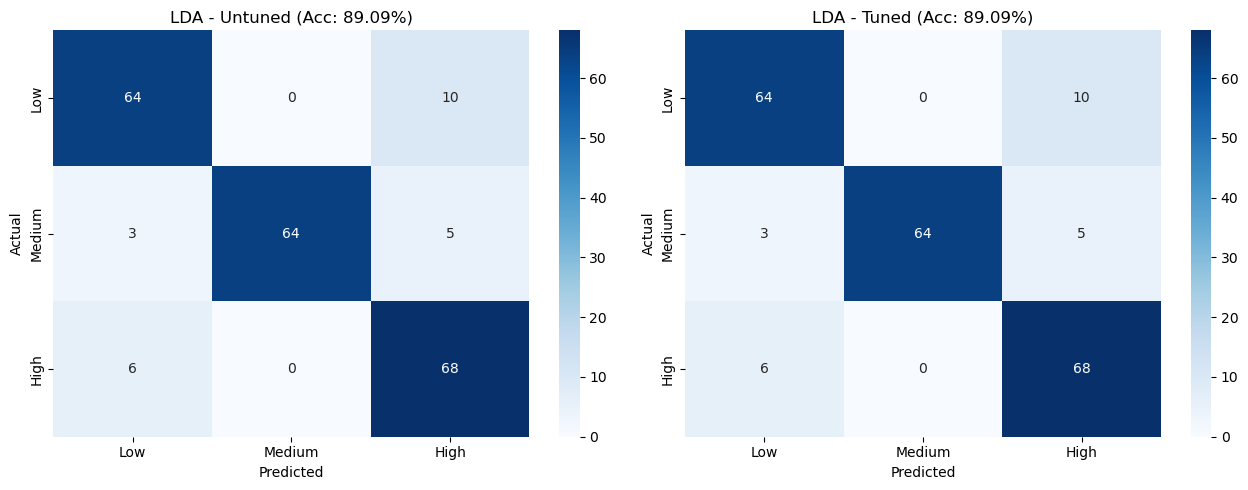

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_tn = confusion_matrix(y_test, tuned_lda_preds)

cm_unt = confusion_matrix(y_test, lda_preds)
sns.heatmap(cm_unt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[0].set_title(f"LDA - Untuned (Acc: {lda_accuracy:.2%})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_tn, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[1].set_title(f"LDA - Tuned (Acc: {tuned_lda_accuracy:.2%})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../results/eda_visualizations/lda_confusion_comparison_tuned_vs_untuned.png", dpi=150, bbox_inches='tight')
plt.show()